<a href="https://colab.research.google.com/github/gabrielfab0022/Image-Deblurring/blob/main/deblurring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
#%matplotlib qt
#%matplotlib notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import clear_output
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Rotinas para implementação da FFT 2d (e sua inversa)

In [ ]:
def fourier_matrix(N):
    F = np.dot(np.array([np.arange(N)]).T, np.array([np.arange(N)]))
    F = (-2*np.pi*1j/N)*F
    F = np.exp(F)
    return F

def DFT_1d(x):
    N = len(x)
    F = fourier_matrix(N)
    X = np.dot(F,x)
    return X

def multiple_DFTs_1d(X):
    N = np.shape(X)[0]
    F = fourier_matrix(N)
    X = np.dot(F,X)
    return X

def multiple_IDFTs_1d(X):
    N = np.shape(X)[0]
    F = np.conj(fourier_matrix(N))
    X = np.dot(F,X)
    return X

def my_fft_1d(x):
    N = len(x)
    if (N%2) != 0:
        X = DFT_1d(x)
    else:
        #recursao
        X1 = my_fft_1d(x[np.arange(0,N, 2)])
        X2 = my_fft_1d(x[np.arange(1,N, 2)])
        D = np.exp((-2*np.pi*1j/N)*np.arange(0,N/2,1))
        first_half = X1 + X2*D
        second_half = X1 - X2*D
        X = np.hstack((first_half, second_half))
    return X


def column_wise_fft(X):
    N = np.shape(X)[0]
    if (N%2) != 0:
        X = multiple_DFTs_1d(X)
    else:
        X1 = column_wise_fft(X[np.arange(0,N,2)])
        X2 = column_wise_fft(X[np.arange(1,N,2)])
        D = np.exp((-2*np.pi*1j/N)*np.array([np.arange(0,N/2,1)]))
        D = D.T
        first_half = X1 + X2*D
        second_half = X1 - X2*D
        X = np.vstack((first_half,second_half))
    return X

def column_wise_ifft(X):
    N = np.shape(X)[0]
    if (N%2) != 0:
        X = multiple_IDFTs_1d(X)
    else:
        X1 = column_wise_ifft(X[np.arange(0,N,2)])
        X2 = column_wise_ifft(X[np.arange(1,N,2)])
        D = np.exp((2*np.pi*1j/N)*np.array([np.arange(0,N/2,1)]))
        D = D.T
        first_half = X1 + X2*D
        second_half = X1 - X2*D
        X = np.vstack((first_half,second_half))
    return X

def my_fft_2d(X):
    Y = column_wise_fft(X)
    Y = (column_wise_fft(Y.T)).T
    Y = Y
    return Y

def my_ifft_2d(X):
    [M,N] = X.shape
    Y = column_wise_ifft(X)
    Y = (column_wise_ifft(Y.T)).T
    Y = Y/(M*N)
    return Y


def fftshift(X):
    (M,N) = X.shape
    half_x = int(np.ceil(M/2))
    half_y = int(np.ceil(N/2))
    Y = np.vstack((X[np.arange(half_x, M),:], X[np.arange(0, half_x),:]))
    Y = np.hstack((Y[:,np.arange(half_y, N)], Y[:,np.arange(0,half_y)]))
    return Y

def ifftshift(X):
    (M,N) = X.shape
    half_x = int(np.floor(M/2))
    half_y = int(np.floor(N/2))
    Y = np.vstack((X[np.arange(half_x, M),:], X[np.arange(0,half_x),:]))
    Y = np.hstack((Y[:,np.arange(half_y, N)],Y[:, np.arange(0,half_y)]))
    return Y

Funções para filtragem

In [ ]:
def convolucao2d(X, kernel):
    #kernel deve ser uma matriz quadrada mxm, com m impar, o comportamento pode ficar estranho se esse nao for o caso
    (mx, nx) = X.shape
    ker_size = kernel.shape[0]
    m = mx - ker_size + 1
    n = nx - ker_size + 1
    Z = np.zeros((m,n)) #onde sera armazenado o resultado
    #rebatendo o kernel
    kernel_rebatido = kernel[np.arange(ker_size-1,-1,-1),:]
    kernel_rebatido = kernel_rebatido[:, np.arange(ker_size-1, -1, -1)]
    for i in range(m):
        for j in range(n):
            Z[i,j] = np.sum(X[i:i+ker_size,j:j+ker_size]*kernel_rebatido)
    return Z

def gaussian_blur_kernel(std): #cria um kernel gaussiano com desvio padrão std
    half_ker = int(np.ceil(2*std))
    ker_size = 2*half_ker+1
    u = np.dot(np.array([np.arange(-half_ker,half_ker+1,1)]).T, np.ones((1, ker_size)))
    v = np.dot(np.ones((ker_size,1)), np.array([np.arange(-half_ker,half_ker+1,1)]))
    kernel = np.exp(-(u**2+v**2)/(2*std**2))
    kernel = kernel/np.sum(kernel)
    return kernel

Funções para fazer transições entre escalas de observação (upsampling e downsampling)

In [ ]:
def bilinear_interp(I, factor):
    [M,N] = I.shape
    coordinates_x = np.array([np.arange(0,M-1,factor)])
    coordinates_y = np.array([np.arange(0,N-1, factor)])
    coordinates_x = np.dot(coordinates_x.T, np.ones((1,len(coordinates_y[0]))))
    coordinates_y = np.dot(np.ones((coordinates_x.shape[0],1)), coordinates_y)
    x1 = np.floor(coordinates_x)
    x2 = np.floor(coordinates_x)+1
    y1 = np.floor(coordinates_y)
    y2 = np.floor(coordinates_y)+1
    Q11 = I[x1.astype(int), y1.astype(int)]
    Q21 = I[x2.astype(int), y1.astype(int)]
    Q12 = I[x1.astype(int), y2.astype(int)]
    Q22 = I[x2.astype(int), y2.astype(int)]
    f_x_y1 = (x2-coordinates_x)*Q11 + (coordinates_x-x1)*Q21
    f_x_y2 = (x2-coordinates_x)*Q12 + (coordinates_x-x1)*Q22
    f = (y2-coordinates_y)*f_x_y1 + (coordinates_y - y1)*f_x_y2
    return f

def bicubic_interp(I, k): #assumindo sempre kernel quadrado e de dimensao impar
    k_old = I.shape[0]
    Ix = I*0
    Ix[1:k_old, :] = I[1:k_old, :] - I[0:k_old-1, :]
    Iy = I*0
    Iy[:, 1:k_old] = I[:, 1:k_old] - I[:, 0:k_old-1]
    Ixy = Ix*0
    Ixy[:,1:k_old] = Ix[:,1:k_old] - Ix[:, 0:k_old-1]
    I_up = np.zeros((k,k))
    coordinates_Ix = np.array([np.arange(-np.floor(k_old/2), np.ceil(k_old/2))])
    coordinates_Ix = np.dot(coordinates_Ix.T, np.ones((1, k_old)))
    coordinates_Iy = coordinates_Ix.T
    coordinates_x = np.array([np.linspace(-np.floor(k_old/2), np.floor(k_old/2), k)])
    coordinates_x = np.dot(coordinates_x.T, np.ones((1,k)))
    coordinates_y = coordinates_x.T
    x1 = np.floor(coordinates_x)
    #x2 = np.floor(coordinates_x)+1
    x2 = np.ceil(coordinates_x)
    y1 = np.floor(coordinates_y)
    #y2 = np.floor(coordinates_y)+1
    y2 = np.ceil(coordinates_y)
    for i in range(k):
        for j in range(k):
            aux_x = np.array([[int(x1[i,j]+np.floor(k_old/2)), int(x1[i,j]+np.floor(k_old/2))], [int(x2[i,j]+np.floor(k_old/2)), int(x2[i,j]+np.floor(k_old/2))]])
            aux_y = np.array([[int(y1[i,j]+np.floor(k_old/2)), int(y2[i,j]+np.floor(k_old/2))], [int(y1[i,j]+np.floor(k_old/2)), int(y2[i,j]+np.floor(k_old/2))]])
            F = np.vstack((np.hstack((I[aux_x, aux_y], Iy[aux_x, aux_y])), np.hstack((Ix[aux_x, aux_y], Ixy[aux_x, aux_y]))))
            aux = np.array([[1, 0, 0, 0], [0, 0, 1, 0], [-3, 3, -2, -1], [2, -2, 1, 1]])
            A = np.dot(aux, F)
            A = np.dot(A, aux.T)
            aux_xx = np.array([[1, (coordinates_x[i,j]-x1[i,j]), (coordinates_x[i,j]-x1[i,j])**2, (coordinates_x[i,j]-x1[i,j])**3]])
            aux_yy = np.array([[1, (coordinates_y[i,j]-y1[i,j]), (coordinates_y[i,j]-y1[i,j])**2, (coordinates_y[i,j]-y1[i,j])**3]])
            new_aux = np.dot(aux_xx, A)
            I_up[i, j] = np.dot(new_aux, aux_yy.T)
    #print(coordinates_x)
    #print(aux_x)
    return I_up


def init_kernel(n):
    kernel = np.zeros((n,n))
    kernel[int((n-1)/2)-1, int((n-1)/2)-1:int((n-1)/2)+1] = 0.5
    return kernel

def downsample_img(I, factor):
    #filtrando a imagem para evitar aliasing
    sig = (1/np.pi)*(1/factor)
    g0 = np.arange(-50, 51, 1)*2*np.pi
    sf=np.exp(-0.5*(g0**2)*(sig**2))
    sf=sf/np.sum(sf)
    csf=np.cumsum(sf)
    csf=np.minimum(csf, csf[::-1])
    sf = sf[csf>0.05]
    blur_kernel = np.dot(sf[:, np.newaxis], sf[np.newaxis, :])
    I_smooth = convolucao2d(I, blur_kernel)
    #fazendo o downsampling
    I_down = bilinear_interp(I_smooth, factor)
    return I_down


Funções para lidar com as fronteiras.
Implementando algoritmo de preenchimento das fronteiras proposto no artigo "REDUCING BOUNDARY ARTIFACTS IN IMAGE DECONVOLUTION", escrito por Renting Liu e Jiaya Jia.

In [ ]:
def column_wise_dst(x): #discrete sine transform
    N = x.shape[0]
    dst_matrix = np.dot(np.array([np.arange(1,N+1, 1)]).T, np.array([np.arange(1,N+1,1)]))
    dst_matrix = np.sin(np.pi*dst_matrix/(N+1))
    X = np.dot(dst_matrix, x)
    return X

def column_wise_idst(x): #inverse discrete sine transform

    N = x.shape[0]
    dst_matrix = np.dot(np.array([np.arange(1,N+1, 1)]).T, np.array([np.arange(1,N+1,1)]))
    dst_matrix = np.sin(np.pi*dst_matrix/(N+1))
    X = (2/(N+1))*np.dot(dst_matrix.T, x)
    return X

def solve_min_laplacian(Al):
    #resolve eq4 de "REDUCING BOUNDARY ARTIFACTS IN IMAGE DECONVOLUTION", por Renting Liu and Jiaya Jia
    [M, N] = Al.shape
    f = np.zeros((M,N))
    boundary_intensities = np.zeros((M,N))
    boundary_intensities[1:M-1, 1:N-1] = -4*Al[1:M-1, 1:N-1] + Al[0:M-2, 1:N-1] + Al[1:M-1, 0:N-2] + Al[1:M-1, 2:N] + Al[2:M, 1:N-1]
    f = f - boundary_intensities
    f = f[1:M-1, 1:N-1]
    #aplicando a dst
    f = column_wise_dst(f) #column-wise
    f = column_wise_dst(f.T).T #row-wise
    x = np.dot(np.array([np.arange(1, M-1, 1)]).T, np.ones((1,N-2)))
    y = np.dot(np.ones((M-2,1)), np.array([np.arange(1, N-1, 1)]))
    scales = (2*np.cos(np.pi*x/(M-1))-2) + (2*np.cos(np.pi*y/(N-1))-2)
    f = f/scales
    #aplicando a idst
    f = column_wise_idst(f) #column-wise
    f = column_wise_idst(f.T).T #row-wise
    result = np.copy(Al)
    result[1:M-1, 1:N-1] = f
    return result

def smooth_pad(I, new_M, new_N):
    # padding proposto em "REDUCING BOUNDARY ARTIFACTS IN IMAGE DECONVOLUTION", por Renting Liu and Jiaya Jia
    if len(I.shape)==3:
        [M,N, n_channels] = I.shape
        result = np.zeros((new_M, new_N, n_channels))
    else:
        [M,N] = I.shape
        result = np.zeros((new_M, new_N))
        n_channels = 1
    diff_M = new_M-M
    diff_N = new_N-N
    for ch in range(n_channels):
        if len(I.shape) == 3:
            Im_ch = I[:,:,ch]
        else:
            Im_ch = I

        #construindo bloco A
        A = np.zeros((diff_M+2, N))
        A[0,:] = Im_ch[-1,:]
        A[-1,:] = Im_ch[0,:]
        A[1:diff_M+1, 0] = np.linspace(A[0,0], A[-1, 0], diff_M)
        A[1:diff_M+1, -1] = np.linspace(A[0,-1], A[-1, -1], diff_M)
        A = solve_min_laplacian(A)

        #construindo bloco B
        B = np.zeros((M, diff_N+2))
        B[:,0] = Im_ch[:,-1]
        B[:,-1] = Im_ch[:,0]
        B[0, 1:diff_N+1] = np.linspace(B[0,0], B[0, -1], diff_N)
        B[-1, 1:diff_N+1] = np.linspace(B[-1,0], B[-1, -1], diff_N)
        B = solve_min_laplacian(B)

        #construindo bloco C
        C = np.zeros((diff_M+2,diff_N+2))
        C[:,0] = A[:, -1]
        C[:,-1] = A[:,0]
        C[0,:] = B[-1,:]
        C[-1,:] = B[0,:]
        C = solve_min_laplacian(C)


        A = A[0:diff_M, :]
        B = B[:, 1:diff_N+1]
        C = C[1:diff_M+1, 1:diff_N+1]


        if len(I.shape) == 3:
            result[:,:,ch] = np.vstack((np.hstack((Im_ch, B)),np.hstack((A,C))))
        else:
            result = np.vstack((np.hstack((Im_ch, B)),np.hstack((A,C))))
    return result

Implementação do algoritmo proposto em "Deblurring Text Images via L0-Regularized Intensity and Gradient Prior", por Jinshan Pan et al.

In [ ]:


##ALGORITMO 1##
def solve_for_x(Fy, Fk, beta, Fu, mu, gv, gh, Fdx, Fdy, accelerate):
    #eq. 8
    M, N = Fy.shape

    g = np.vstack(((gv[M-1,:]-gv[0,:])[np.newaxis, :], gv[0:M-1,:]-gv[1:M,:])) + np.hstack(((gh[:,N-1]-gh[:,0])[:,np.newaxis], gh[:,0:N-1]-gh[:,1:N]))
    if accelerate is True:
        Fg = np.fft.fft2(g)
    else:
        Fg = my_fft_2d(g)

    #otimização
    Fx = (np.conj(Fk)*Fy + beta*Fu + mu*Fg)/(np.conj(Fk)*Fk + beta + mu*(np.conj(Fdx)*Fdx + np.conj(Fdy)*Fdy))
    if accelerate is True:
        x = np.real(np.fft.ifft2(Fx))
    else:
        x = np.real(my_ifft_2d(Fx))
    return x

def solve_for_u(x, lambd, sigma, beta):
    u = x*(((np.abs(x))**2)>= lambd*sigma/beta)
    return u

def solve_for_g(x, lambd, mu, Fdx, Fdy):
    M, N = x.shape
    x_gradx = np.vstack((-x[0:M-1,:]+x[1:M,:], (-x[M-1, :]+x[0,:])[np.newaxis,:]))
    x_grady = np.hstack((-x[:,0:N-1]+x[:,1:N], (-x[:,N-1]+x[:,0])[:, np.newaxis]))
    grad_mag = x_gradx**2 + x_grady**2
    gv = x_gradx*(grad_mag >= lambd/mu)
    gh = x_grady*(grad_mag >= lambd/mu)
    return gv, gh

def update_image(Fy, y, Fk, Fdx, Fdy, lambd, accelerate, sigma = 1):
    beta_max = 2**3
    mu_max = 1e+5
    x = np.copy(y)
    beta = 2*lambd*sigma
    #cnt = 0
    while(beta<beta_max):
        #cnt = cnt+1
        u = solve_for_u(x, lambd, sigma, beta)
        if accelerate is True:
            Fu = np.fft.fft2(u)
        else:
            Fu = my_fft_2d(u)
        mu = 2*lambd
        while(mu<mu_max):
            gv, gh = solve_for_g(x, lambd, mu, Fdx, Fdy)
            x = solve_for_x(Fy, Fk, beta, Fu, mu, gv, gh, Fdx, Fdy, accelerate)
            mu = 2*mu
        beta = 2*beta
    #print(cnt)
    return x

def find_x_no_grad(y, ker, lambd, accelarate):

    My, Ny = y.shape
    ks = ker.shape[0]
    y_pad = smooth_pad(y, int(My+2*np.floor(ks/2)), int(Ny+2*np.floor(ks/2)))
    [M,N] = y_pad.shape

    Fy = my_fft_2d(y_pad)

    #encontrando função de transferência do gradiente na direção x
    dx = np.array([[0, 1, 0], [0, -1, 0], [0, 0, 0]])
    dx_pad = np.zeros((M,N))
    dx_pad[0:3, 0:3] = dx
    dx_pad = np.vstack((np.hstack((dx_pad, dx_pad)), np.hstack((dx_pad, dx_pad))))
    dx_pad = dx_pad[1:1+M, 1:1+N]
    Fdx = my_fft_2d(dx_pad)

    #encontrando função de transferência do gradiente na direção y
    dy = np.array([[0, 0, 0], [1, -1, 0], [0, 0, 0]])
    dy_pad = np.zeros((M,N))
    dy_pad[0:3, 0:3] = dy
    dy_pad = np.vstack((np.hstack((dy_pad, dy_pad)), np.hstack((dy_pad, dy_pad))))
    dy_pad = dy_pad[1:1+M, 1:1+N]
    Fdy = my_fft_2d(dy_pad)

    #encontrando função de transferência do blurring
    k_pad = np.zeros((M,N))
    k_pad[0:ks, 0:ks] = ker
    k_pad = np.vstack((np.hstack((k_pad, k_pad)), np.hstack((k_pad, k_pad))))
    origin = int(np.floor(ks/2))
    k_pad = k_pad[origin:origin+M, origin:origin+N]
    Fk = my_fft_2d(k_pad)

    mu_max = 1e+5
    mu = 2*lambd
    x = np.copy(y_pad)
    while mu < mu_max:
        gv, gh = solve_for_g(x, lambd, mu, Fdx, Fdy)
        x = solve_for_x(Fy, Fk, 0, 0, mu, gv, gh, Fdx, Fdy, accelerate)
        mu = 2*mu
    x = x[:My, :Ny]
    x[x>1] = 1
    x[x<0] = 0
    return x



#ESTIMANDO KERNEL
def correct_center(ker):
    ksize = ker.shape[0]
    aux = np.array([np.arange(1, ksize+1, 1)])
    Mx = np.dot(np.ones((ksize,1)), aux)
    My = np.dot(aux.T, np.ones((1,ksize)))
    #encontrando coordenadas do centroide
    Cx = np.sum(ker*Mx)
    Cy = np.sum(ker*My)
    diff_x = np.round(np.floor((ksize+1)/2)-Cx)
    diff_y = np.round(np.floor((ksize+1)/2)-Cy)
    #encontrando as novas coordenadas
    A = np.array([[1, 0, diff_y], [0, 1, diff_x]])
    coords = np.vstack((My.flatten(), Mx.flatten()))
    coords = np.vstack((coords, np.ones((1,ksize**2))))
    new_coords = np.dot(A, coords)
    coords = coords[0:2, :] #removendo a coluna de 1's
    #removendo coordenadas fora dos limites
    keep = (new_coords[0,:]<=ksize) & (new_coords[0,:]>=1)
    new_coords = new_coords[:, keep]
    coords = coords[:,keep]
    keep = (new_coords[1,:]<=ksize) & (new_coords[1,:]>=1)
    new_coords = new_coords[:, keep]
    coords = coords[:,keep]
    new_coords = new_coords.astype(int)
    coords = coords.astype(int)
    result = ker*0
    result[new_coords[0,:]-1, new_coords[1,:]-1] = ker[coords[0,:]-1, coords[1,:]-1]
    return result

def update_ker(y, x, gamma, ksize):
    [M,N] = y.shape
    #gamma = 4
    x_pad = smooth_pad(x, M, N)
    bx = np.hstack((np.array([y[:,-1]-y[:,0]]).T, y[:,0:N-1]-y[:,1:N]))
    by = np.vstack((np.array([y[-1,:]-y[0,:]]), y[0:M-1,:]-y[1:M,:]))
    x_pad_x = np.hstack((np.array([x_pad[:,-1]-x_pad[:,0]]).T, x_pad[:,0:N-1]-x_pad[:,1:N]))
    x_pad_y = np.vstack((np.array([x_pad[-1,:]-x_pad[0,:]]), x_pad[0:M-1,:]-x_pad[1:M,:]))
    Fbx = my_fft_2d(bx)
    Fby = my_fft_2d(by)
    Fx_pad_x = my_fft_2d(x_pad_x)
    Fx_pad_y = my_fft_2d(x_pad_y)
    Fk = (Fbx*np.conj(Fx_pad_x) + Fby*np.conj(Fx_pad_y))/(Fx_pad_x*np.conj(Fx_pad_x) + gamma + Fx_pad_y*np.conj(Fx_pad_y))
    k = np.real(my_ifft_2d(Fk))
    ker1 = np.hstack((k[int(M-np.floor(ksize/2)):M, int(N-np.floor(ksize/2)):N], k[int(M-np.floor(ksize/2)):M, 0:int(np.ceil(ksize/2))]))
    ker2 = np.hstack((k[0:int(np.ceil(ksize/2)), int(N-np.floor(ksize/2)):N], k[0:int(np.ceil(ksize/2)), 0:int(np.ceil(ksize/2))]))
    ker = np.vstack((ker1, ker2))
    ker[ker < 0.05*np.max(ker)] = 0
    ker[ker<0] = 0
    ker = ker/np.sum(ker)
    ker = correct_center(ker)
    ker[ker<0] = 0
    ker = ker/np.sum(ker)
    return ker

#ALGORITMO 2

def single_scale_processing(y, ker, lambd, scale, gamma, accelerate):
    ks = ker.shape[0]
    [My,Ny] = y.shape
    y_pad = smooth_pad(y, int(My+2*np.floor(ks/2)), int(Ny+2*np.floor(ks/2)))
    [M,N] = y_pad.shape
    new_lambd = np.copy(lambd)

    #necessary fft's
    Fy = my_fft_2d(y_pad)


    #finding transfer function of gradient in the x direction
    dx = np.array([[0, 1, 0], [0, -1, 0], [0, 0, 0]])
    dx_pad = np.zeros((M,N))
    dx_pad[0:3, 0:3] = dx
    dx_pad = np.vstack((np.hstack((dx_pad, dx_pad)), np.hstack((dx_pad, dx_pad))))
    dx_pad = dx_pad[1:1+M, 1:1+N]
    Fdx = my_fft_2d(dx_pad)

    #finding transfer function of gradient in the y direction
    dy = np.array([[0, 0, 0], [1, -1, 0], [0, 0, 0]])
    dy_pad = np.zeros((M,N))
    dy_pad[0:3, 0:3] = dy
    dy_pad = np.vstack((np.hstack((dy_pad, dy_pad)), np.hstack((dy_pad, dy_pad))))
    dy_pad = dy_pad[1:1+M, 1:1+N]
    Fdy = my_fft_2d(dy_pad)

    for i in range(5):
        print("Iteração ", i)
        #finding transfer function of the blurring
        k_s = ker.shape[0] #k_size
        k_pad = np.zeros((M,N))
        k_pad[0:k_s, 0:k_s] = ker
        k_pad = np.vstack((np.hstack((k_pad, k_pad)), np.hstack((k_pad, k_pad))))
        origin = int(np.floor(k_s/2))
        k_pad = k_pad[origin:origin+M, origin:origin+N]
        Fk = my_fft_2d(k_pad)
        x = update_image(Fy, y_pad,  Fk, Fdx, Fdy, new_lambd, accelerate)
        x = x[:My, :Ny]
        ker = update_ker(y_pad, x, gamma, ks)
        new_lambd = np.max(((new_lambd/1.1), 1e-4))
        #print(new_lambd)
        x[x<0] = 0
        x[x>1] = 1
    return x, ker, new_lambd #alterar aqui para retornar new_lambd caso dê ruim

#geral
def multiscale_processing(y, gamma_correction, ksize, lambd, gamma, accelerate):
    yc = y**gamma_correction
    factor = np.sqrt(0.5)
    num_scales = np.floor(np.log(5/ksize)/np.log(factor))+1
    scales = factor**(np.arange(0, num_scales, 1))
    ksizes = np.ceil(scales*ksize)
    ksizes = ksizes + ((ksizes%2)==0)
    ksizes = ksizes.astype(int)
    new_lambd = np.copy(lambd)
    for i in np.arange(len(scales)-1, -1, -1):
        print(i)
        if i == len(scales)-1:
            ker = init_kernel(ksizes[i])
        else:
            ker = bicubic_interp(ker, ksizes[i])
        #print(ker.shape)
        y_down = downsample_img(yc, 1/scales[i])
        #print(y_down.shape)
        x, ker, new_lambd = single_scale_processing(y_down, ker, new_lambd, i-(len(scales)-1), gamma, accelerate)
        clear_output(wait=True)
    return x,ker


Implementação do algoritmo de deconvolução não cega proposto em "Fast Image Deconvolution using Hyper-Laplacian Priors", por Dilip Krishnan e Rob Fergus.

In [ ]:
def find_w(v, beta):
    epsilon = 1e-4
    m = 8/(27*beta**3)
    t1 = (-9/8)*v**2
    t2 = (v**3)/4
    t3 = (-1/8)*m*v**2
    t4 = -t3/2 + np.emath.sqrt((-1/27)*m**3 + (1/256)*(m**2)*(v**4))
    t5 = t4**(1/3)
    t6 = 2*((-5/18)*t1 + t5 + m/(3*t5))
    t7 = np.emath.sqrt((t1/3) + t6)
    r1 = 3*v/4 + (t7 + np.emath.sqrt(-(t1 + t6 + t2/t7)))/2
    r2 = 3*v/4 + (t7 - np.emath.sqrt(-(t1 + t6 + t2/t7)))/2
    r3 = 3*v/4 + (-t7 + np.emath.sqrt(-(t1 + t6 - t2/t7)))/2
    r4 = 3*v/4 + (-t7 - np.emath.sqrt(-(t1 + t6 - t2/t7)))/2
    r = [r1, r2, r3, r4]
    c1 = [np.abs(np.imag(ri))< epsilon for ri in r]
    c2 = [np.real(ri)*np.sign(v) > 0.5*np.abs(v) for ri in r]
    c3 = [np.real(ri)*np.sign(v) < np.abs(v) for ri in r]
    w = np.maximum.reduce([(c1i & c2i & c3i)*np.real(ri)*np.sign(v) for c1i, c2i, c3i, ri in zip(c1, c2, c3, r)])*np.sign(v)
    return w

def find_x_hyper_laplacian(Fy, Fk, Fdx, Fdy, wx, wy, beta, lambd):
    #FFT's necessárias
    Fwx = np.fft.fft2(wx)
    Fwy = np.fft.fft2(wy)
    Fx = (lambd*np.conj(Fk)*Fy + beta*np.conj(Fdx)*Fwx + beta*np.conj(Fdy)*Fwy)/(lambd*np.conj(Fk)*Fk + beta*np.conj(Fdx)*Fdx + beta*np.conj(Fdy)*Fdy)
    x = np.real(np.fft.ifft2(Fx))
    return x

def hyper_laplacian_deconvolution(y, ker, lambd, beta_0=1, beta_inc=2, beta_max=0.001):
    My, Ny = y.shape
    ks = ker.shape[0]
    y_pad = smooth_pad(y, int(My+2*np.floor(ks/2)), int(Ny+2*np.floor(ks/2)))
    [M,N] = y_pad.shape

    Fy = my_fft_2d(y_pad)

    #encontrando a função de transferência dos gradientes na direção x
    dx = np.array([[0, 1, 0], [0, -1, 0], [0, 0, 0]])
    dx_pad = np.zeros((M,N))
    dx_pad[0:3, 0:3] = dx
    dx_pad = np.vstack((np.hstack((dx_pad, dx_pad)), np.hstack((dx_pad, dx_pad))))
    dx_pad = dx_pad[1:1+M, 1:1+N]
    Fdx = my_fft_2d(dx_pad)

    #encontrando a função de transferência dos gradientes na direção y
    dy = np.array([[0, 0, 0], [1, -1, 0], [0, 0, 0]])
    dy_pad = np.zeros((M,N))
    dy_pad[0:3, 0:3] = dy
    dy_pad = np.vstack((np.hstack((dy_pad, dy_pad)), np.hstack((dy_pad, dy_pad))))
    dy_pad = dy_pad[1:1+M, 1:1+N]
    Fdy = my_fft_2d(dy_pad)

    #encontrando a função de transferência dos gradientes na direção x
    k_pad = np.zeros((M,N))
    k_pad[0:ks, 0:ks] = ker
    k_pad = np.vstack((np.hstack((k_pad, k_pad)), np.hstack((k_pad, k_pad))))
    origin = int(np.floor(ks/2))
    k_pad = k_pad[origin:origin+M, origin:origin+N]
    Fk = my_fft_2d(k_pad)

    beta = np.copy(beta_0)
    x = np.copy(y_pad)

    while (beta>beta_max):
        vx = np.vstack(((x[M-1,:]-x[0,:])[np.newaxis,:], x[0:M-1,:]-x[1:,:]))
        vy = np.hstack(((x[:,N-1]-x[:,0])[:,np.newaxis], x[:,0:N-1]-x[:,1:]))
        wx = find_w(vx, beta)
        wy = find_w(vy, beta)
        x = find_x_hyper_laplacian(Fy, Fk, Fdx, Fdy, wx, wy, beta, lambd)
        beta = beta/beta_inc
    x[x<0] = 0
    x[x>1] = 1
    return x[0:My, 0:Ny]

Filtro bilateral

In [ ]:
def bilateral_filter(I, sigma_s, sigma_r, d = 9):
    M, N, D = I.shape
    coords_x = np.arange(int(-np.floor(d/2)), int(np.ceil(d/2)), 1)
    coords_y = np.arange(int(-np.floor(d/2)), int(np.ceil(d/2)), 1)
    X = np.dot(coords_x[:, np.newaxis], np.ones((1,d)))
    Y = np.dot(np.ones((d,1)), coords_y[np.newaxis, :])
    spatial_term = (X**2 + Y**2)/(sigma_s**2)
    I_filtered = I*0
    I_pad = np.zeros((M+2*int(np.floor(d/2)), N+2*int(np.floor(d/2)),D))
    I_pad[int(np.floor(d/2)):int(np.floor(d/2))+M, int(np.floor(d/2)):int(np.floor(d/2))+N, :] = I
    for i in range(M):
        for j in range(N):
            intensity_term = np.sum((I_pad[i:i+d, j:j+d, :]-I[i,j,:].reshape(1,1,-1))**2, axis = 2)/(sigma_r**2)
            wij = np.exp(-0.5*(spatial_term+intensity_term))
            denom = np.sum(wij)
            I_filtered[i,j,0] = np.sum(I_pad[i:i+d,j:j+d,0]*wij)/(denom)
            I_filtered[i,j,1] = np.sum(I_pad[i:i+d,j:j+d,1]*wij)/(denom)
            I_filtered[i,j,2] = np.sum(I_pad[i:i+d,j:j+d,2]*wij)/(denom)
    return I_filtered

Filtragem bilateral


Text(0.5, 1.0, 'Resultado')

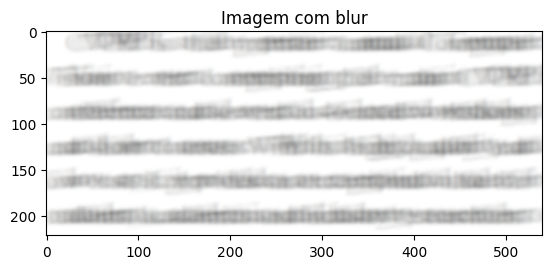

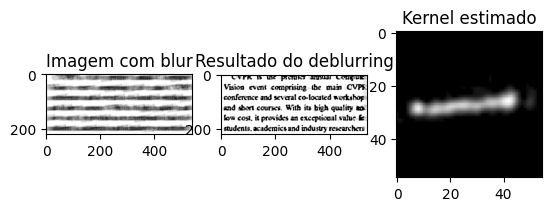

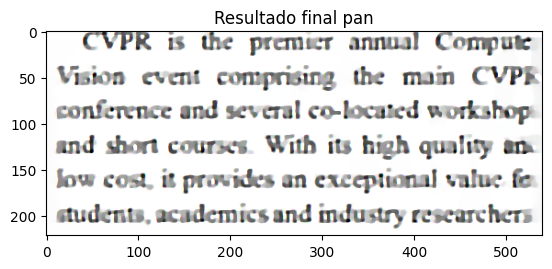

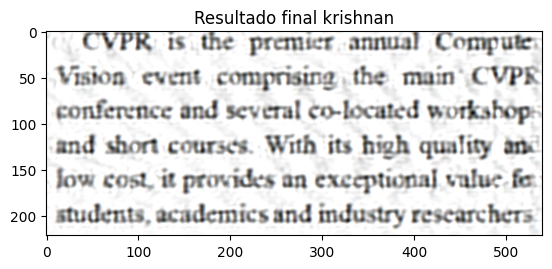

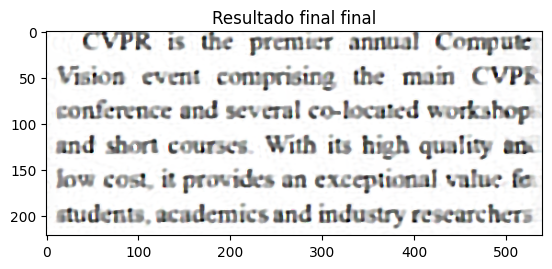

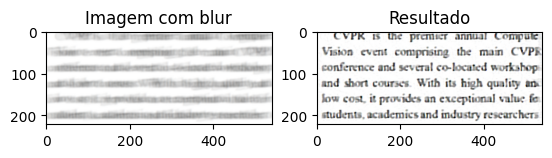

In [ ]:
#path = 'C:\\Users\\Gabriel\\Desktop\\disciplinas aluno especial 2024\\Visão Computacional\\Projeto Final\\imagens\\'
path = '/content/drive/My Drive/imagens/'

accelerate = True



y = mpimg.imread(path+'new_test_img_blur.png')
gamma_correction = 2.2
ksize = 55
lambd = 4e-3
gamma = 2


'''
y = mpimg.imread(path+'test3_blur_55.png')
gamma_correction = 1
ksize = 69
lambd = 4e-3
gamma = 2
'''



'''

y = mpimg.imread(path+'0015_blur65.png')
gamma_correction = 2.2
ksize = 67
lambd = 4e-3
gamma = 4
'''



'''
y = mpimg.imread(path+'eccv3_blurred.png')
gamma_correction = 1
ksize = 23
lambd = 4e-3
gamma = 0.4
'''




''''
y = mpimg.imread(path+'new_test_img12_blur_129.png')
gamma_correction = 1
ksize = 131
lambd = 4e-3
gamma = 4.2
'''



'''
y = mpimg.imread(path+'blurred_cho.png')
gamma_correction = 1
ksize = 23
lambd = 4e-3
gamma = 1
'''

'''
y = mpimg.imread(path+'im15_ker04_blur.png')
gamma_correction = 1
ksize = 27
lambd = 4e-3
gamma = 4
'''


'''
y = mpimg.imread(path+'postcard.png')
gamma_correction = 2.2
ksize = 91
lambd = 4e-3
gamma = 3 #verificar se esse é o melhor mesmo depois do "removing ringing artifacts"
'''

'''
y = mpimg.imread(path+'color_patch_blur_99.png')
gamma_correction = 1
ksize = 99
lambd = 4e-3
gamma = 4
'''


'''
y = mpimg.imread(path+'im06_ker01_blur.png')
gamma_correction = 1
ksize = 19
lambd = 4e-3
gamma = 4
'''


'''
y = mpimg.imread(path+'boat_input.png')
gamma_correction = 2.2
ksize = 25
lambd = 4e-3
gamma = 4 #verificar se esse é o melhor mesmo depois do "removing ringing artifacts"
'''

'''
y = mpimg.imread(path+'fountain1_blurry.png')
gamma_correction = 1
ksize = 41
lambd = 4e-3
gamma = 5 #verificar se esse é o melhor mesmo depois do "removing ringing artifacts"
'''


'''
y = mpimg.imread(path+'dragon_patch_use.png')
gamma_correction = 2.2
ksize = 45
lambd = 4e-3
gamma = 4
'''


'''
y = mpimg.imread(path+'my_shufa_image_blur_121.png')
gamma_correction = 2.2
ksize = 111
lambd = 4e-3
gamma = 4
'''

'''
y = mpimg.imread(path+'new_test_img10_blur.png')
gamma_correction = 2.2
ksize = 85
lambd = 4e-3
gamma = 4
'''

'''
y = mpimg.imread(path+'new_test_img10_blur.png')
gamma_correction = 2.2
ksize = 85
lambd = 4e-3
gamma = 4
'''


y_gray = 0.299*y[:,:,0] + 0.587*y[:,:,1] + 0.114*y[:,:,2]
x, ker = multiscale_processing(y_gray, gamma_correction, ksize, lambd, gamma, accelerate)

clear_output(wait=True)
print('Deconvolução não cega')
result_pan = y*0
for channel in range(3):
    result_pan[:,:,channel] = find_x_no_grad(y[:,:,channel], ker, 1e-4, accelerate)


result_krishnan = y*0
for channel in range(3):
    result_krishnan[:,:,channel] = hyper_laplacian_deconvolution(y[:,:,channel], ker, 1)


clear_output(wait=True)
print('Filtragem bilateral')
diff = result_krishnan-result_pan
#plt.figure()
#plt.imshow(diff)
filtered_difference = bilateral_filter(diff, 2, 0.1)
final_result = result_krishnan - filtered_difference



norm_ker = (ker - np.min(ker))/(np.max(ker)-np.min(ker))


plt.figure()
plt.imshow(y)
plt.title('Imagem com blur')

plt.figure()
plt.subplot(131)
plt.imshow(y_gray, cmap = 'gray')
plt.title('Imagem com blur')
plt.subplot(132)
plt.imshow(x, cmap = 'gray')
plt.title('Resultado do deblurring')
plt.subplot(133)
plt.imshow(norm_ker, cmap = 'gray')
plt.title('Kernel estimado')

plt.figure()
plt.imshow(result_pan)
plt.title('Resultado final pan')

plt.figure()
plt.imshow(result_krishnan)
plt.title('Resultado final krishnan')

plt.figure()
plt.imshow(final_result)
plt.title('Resultado final final')

plt.figure()
plt.subplot(121)
plt.imshow(y)
plt.title('Imagem com blur')
plt.subplot(122)
plt.imshow(final_result)
plt.title('Resultado')

